# Predicting Real Estate Asset Value: Micro-Features, Macro-Trends, and Latent Market Segments
**Date:** April 2, 2026

**Group:** Matei Ghiorghiu, Matei Vucenovic, Sidon Mengsteab, Kiju Kim, Lloyd Nsambu



In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.linear_model import Ridge, LogisticRegression
from sklearn.metrics import mean_squared_error, r2_score, classification_report, roc_curve, auc
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

ames_df = pd.read_csv('train.csv')
hpi_df = pd.read_csv('ATNHPIUS11180Q.csv')

#Combine all floors and basement into Total Square Footage
ames_df["Total_Square_Footage"] = ames_df["TotalBsmtSF"]+ames_df["1stFlrSF"]+ames_df["2ndFlrSF"]

#Convert month sold into a financial quarter
def get_quarter_start(month):
  if month in [1,2,3]: return "01" # Quarter 1
  if month in [4,5,6]: return "04" # Quarter 2
  if month in [7,8,9]: return "07" # Quarter 3
  if month in [10,11,12]: return "10" # Quarter 4

ames_df["QuarterMonth"] = ames_df["MoSold"].apply(get_quarter_start)

#Make a stadard date string (YYYY-MM-DD) and convert both to date time

ames_df["Quarter_start"] = ames_df["YrSold"].astype(str) + "-" + ames_df["QuarterMonth"] + "-01"
ames_df["Quarter_start"] = pd.to_datetime(ames_df["Quarter_start"])
hpi_df["observation_date"] = pd.to_datetime(hpi_df["observation_date"])

#Join both datasets

augmented_df = pd.merge(left = ames_df, right = hpi_df, left_on = "Quarter_start", right_on = "observation_date", how = "left")

augmented_df.rename(columns= {"ATNHPIUS11180Q":"HPI_Score"}, inplace = True)

augmented_df.head(5)


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,MoSold,YrSold,SaleType,SaleCondition,SalePrice,Total_Square_Footage,QuarterMonth,Quarter_start,observation_date,HPI_Score
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,2,2008,WD,Normal,208500,2566,01,2008-01-01,2008-01-01,169.56
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,5,2007,WD,Normal,181500,2524,04,2007-04-01,2007-04-01,168.94
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,9,2008,WD,Normal,223500,2706,07,2008-07-01,2008-07-01,166.76
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,2,2006,WD,Abnorml,140000,2473,01,2006-01-01,2006-01-01,163.25
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,12,2008,WD,Normal,250000,3343,10,2008-10-01,2008-10-01,166.92


### **Introduction**
In our Midterm Project, we established that micro-level features (such as `GrLivArea` and `OverallQual`) outperform macroeconomic indicators (Federal Reserve HPI) when try to determine the value of homes in Ames, Iowa.

For this Final Project, our goal is to build automated valuation models. To achieve this:

**Research Question**:
Can we build reliable machine learning models using house features and market tiers to predict exact house prices and classify if a home is a "premium" property?

**Feature Engineering and EDA**:
We will make new metrics and visualize the distributions in the market.

**Clustering**:
We will use K-Means clustering to identify market segments in Ames that satisfy the advanced modelling requirement.

**Regression**:
We will use Ridge Regression paired with Cross-Validation to solve issues found in our baseline models, and also analyzing the bias-variance tradeoff.

**Classification**:
We will finally develop a classification model to predict whether or not a property will sell at a "Market Premium".

# Feature Engineering

In [ ]:
# determining the age of the houses at their sale date...
augmented_df['HouseAge_AtSale'] = augmented_df['YrSold'] - augmented_df['YearBuilt']

# price per Square Foot
augmented_df['PricePerSqFt'] = augmented_df['SalePrice'] / augmented_df['GrLivArea']

# total bathrooms (combines full, half, and basement baths)
augmented_df['TotalBathrooms'] = augmented_df['FullBath'] + (0.5 * augmented_df['HalfBath']) + augmented_df['BsmtFullBath'] + (0.5 * augmented_df['BsmtHalfBath'])

# determining the decade a house was built
augmented_df['DecadeBuilt'] = (augmented_df['YearBuilt'] // 10)*10
augmented_df['DecadeBuilt'] = augmented_df['DecadeBuilt'].astype(str) + 's'

# target for our later classification model... will be used much later in the analysis
median_price = augmented_df['SalePrice'].median()
augmented_df['Is_Premium'] = (augmented_df['SalePrice'] > median_price).astype(int)

# dataset cleaning for modelling
features = ['GrLivArea', 'OverallQual', 'HouseAge_AtSale', 'TotalBathrooms', 'GarageArea', 'HPI_Score']
df = augmented_df.dropna(subset=features + ['SalePrice'])

df.head(5)

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,Total_Square_Footage,QuarterMonth,Quarter_start,observation_date,HPI_Score,HouseAge_AtSale,PricePerSqFt,TotalBathrooms,DecadeBuilt,Is_Premium
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,2566,01,2008-01-01,2008-01-01,169.56,5,121.929825,3.5,2000s,1
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,2524,04,2007-04-01,2007-04-01,168.94,31,143.819334,2.5,1970s,1
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,2706,07,2008-07-01,2008-07-01,166.76,7,125.139978,3.5,2000s,1
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,2473,01,2006-01-01,2006-01-01,163.25,91,81.537566,2.0,1910s,0
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,3343,10,2008-10-01,2008-10-01,166.92,8,113.739763,3.5,2000s,1


### **Interpretation**:

We engineered 5 new features for our models. `HouseAge_AtSale` shows how old the house was when bought. `TotalBathrooms` combines multiple bathroom columns into one simple number. `DecadeBuilt` shows what decade the homes were built in. `PricePerSqFt` shows the price per square foot of the home, and `Is_Premium` gives us a target to predict for our classification model.

# Exploratory Data Analysis
Exploring general insights from the data and ploting them.

/tmp/ipykernel_455/1436398791.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df.sort_values('DecadeBuilt'), x='DecadeBuilt', y='SalePrice', palette='Blues', ax=axes[2])


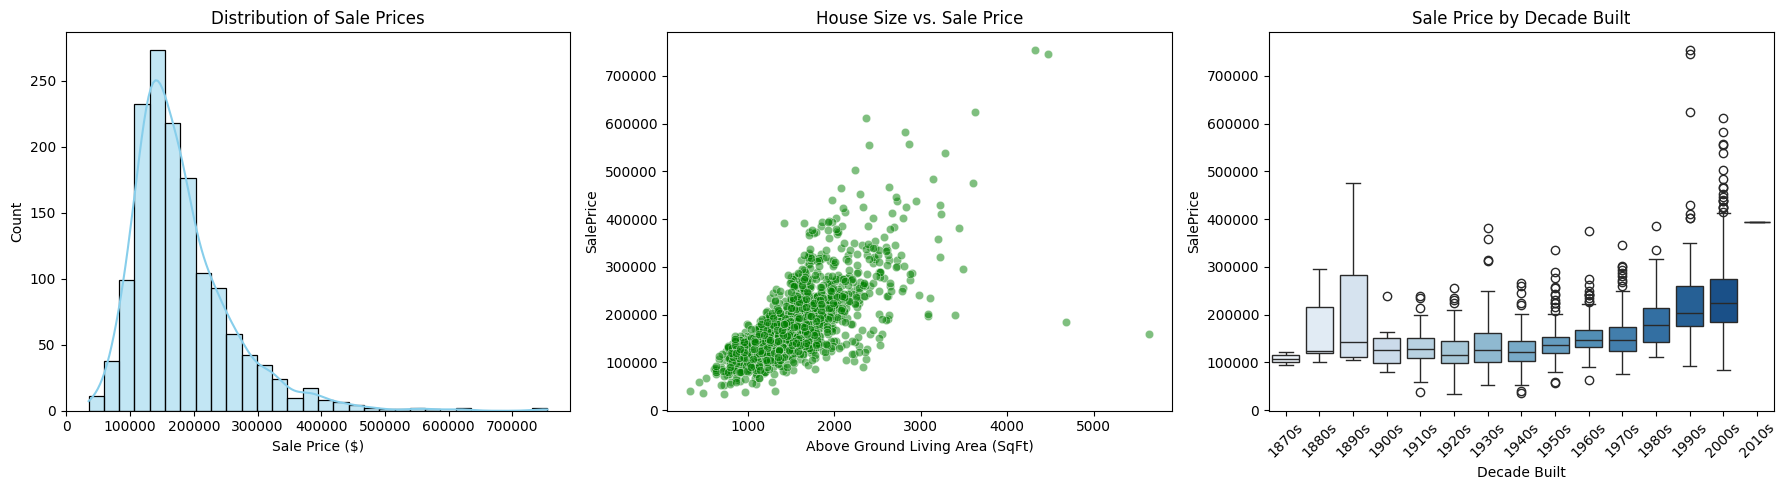

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# plot 1: aiming to display a histogram of a distribution of prices...
sns.histplot(df['SalePrice'], bins=30, kde=True, color='skyblue', ax=axes[0])
axes[0].set_title('Distribution of Sale Prices')
axes[0].set_xlabel('Sale Price ($)')

# plot 2: here we want to explore the relation between size vs price with a scatterplot
sns.scatterplot(data=df, x='GrLivArea', y='SalePrice', alpha=0.5, color='green', ax=axes[1])
axes[1].set_title('House Size vs. Sale Price')
axes[1].set_xlabel('Above Ground Living Area (SqFt)')

# plot 3: aiming to make viualisation of the distribution of prices for each decade..starting from 1870s
sns.boxplot(data=df.sort_values('DecadeBuilt'), x='DecadeBuilt', y='SalePrice', palette='Blues', ax=axes[2])
axes[2].set_title('Sale Price by Decade Built')
axes[2].set_xlabel('Decade Built')
axes[2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

### **Interpretations**

**Plot 1**: This histogram shows that most houses are sold between the 100,000 to 200,000 dollar price range. The histogram also has a right skew to it, likely because of the outlier houses that were sold at a much higher price.

**Plot 2**: This scatterplot shows the relationship between square footage and house price. We can clearly see that as the square footage of the house goes up, the price also goes up, indicating a positive linear relationship between the two variables.

**Plot 3**: This boxplot shows the relation between the year the house was built and its sale price. We can see that the median price of newer homes (built in the 1990s and 2000s) have a higher median price compared to older homes. It also shows that these newer homes have a much wider range of prices compared to the older homes.

# Clustering

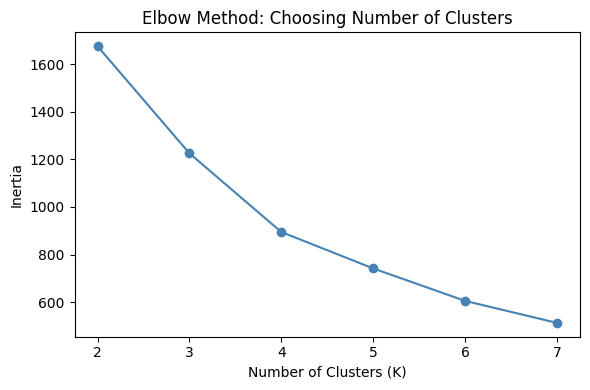

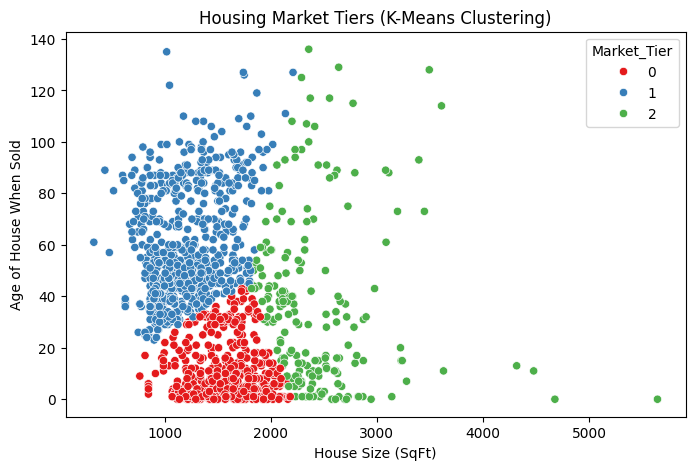

In [ ]:
# Pick features for clustering
scaler_cluster = StandardScaler()
X_cluster = scaler_cluster.fit_transform(df[['GrLivArea', 'HouseAge_AtSale']])

# Elbow method to justify K=3
inertias = []
k_range = range(2, 8)
for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_cluster)
    inertias.append(km.inertia_)

plt.figure(figsize=(6, 4))
plt.plot(k_range, inertias, marker='o', color='steelblue')
plt.title('Elbow Method: Choosing Number of Clusters')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')
plt.tight_layout()
plt.show()
# K-Means Clustering
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df['Market_Tier'] = kmeans.fit_predict(X_cluster)

# Visualize the clusters
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x='GrLivArea', y='HouseAge_AtSale', hue='Market_Tier', palette='Set1')
plt.title('Housing Market Tiers (K-Means Clustering)')
plt.xlabel('House Size (SqFt)')
plt.ylabel('Age of House When Sold')
plt.show()

### **Interpretation**

The elbow plot showed that inertia drops sharply up to K=3 and levels off
afterward, confirming 3 as the optimal number of clusters.

Using K-Means, we grouped the homes into 3 "tiers" based on size and age of the house.

**Tier 0:** This is for homes that are older and smaller.

**Tier 1:** This is for homes that are newer and average sized.

**Tier 2:** This is for homes that have various ages and are larger (Luxury houses).

We will use these K-Mean clustering labels as a new feature to enhance our predictions.

# Regression and Regularization

To begin the regression section, we selected key structural and market-level predictors of house prices, including living area, quality, age at sale, bathrooms, garage area, the HPI score, and the market tier created in the clustering section. We then split the data into training and testing sets so the model could be evaluated on unseen observations. Finally, we standardized the predictors because regularized regression methods such as Ridge are sensitive to variable scale.

In [ ]:
reg_features = ['GrLivArea', 'OverallQual', 'HouseAge_AtSale', 'TotalBathrooms', 'GarageArea', 'HPI_Score', 'Market_Tier']

reg_df = df.loc[:, reg_features + ['SalePrice']].dropna().copy()

X_reg = pd.get_dummies(reg_df[reg_features], columns=['Market_Tier'], drop_first=True)
y_reg = reg_df['SalePrice']

X_train, X_test, y_train, y_test = train_test_split(X_reg, y_reg, test_size=0.2, random_state=42)

scaler_reg = StandardScaler()
X_train_scaled = scaler_reg.fit_transform(X_train)
X_test_scaled = scaler_reg.transform(X_test)

print(f"Training set: {X_train.shape[0]} homes | Test set: {X_test.shape[0]} homes")

Training set: 1168 homes | Test set: 292 homes


Optimal L2 Penalty (Alpha): 10.0
Out-of-Sample Test RMSE: $40,477.70
Out-of-Sample Test R-Squared: 0.786


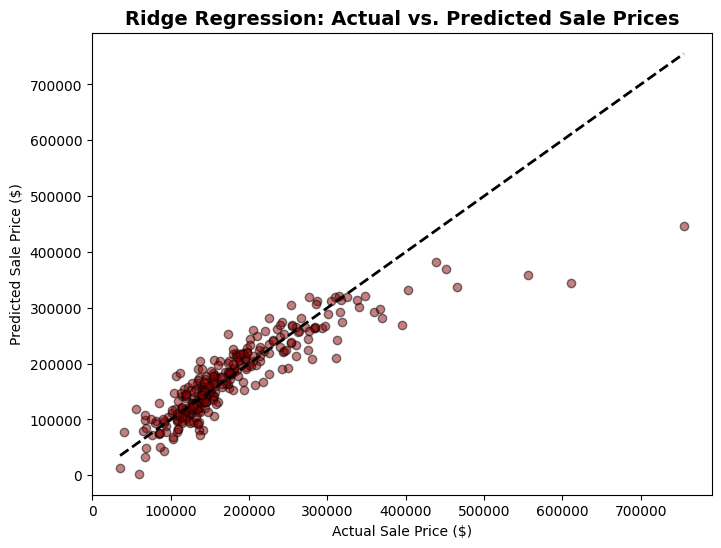

In [ ]:
ridge_cv = GridSearchCV(Ridge(), {'alpha': [0.1, 1.0, 10.0, 100.0, 500.0]}, cv=5, scoring='neg_mean_squared_error')
ridge_cv.fit(X_train_scaled, y_train)

best_ridge = ridge_cv.best_estimator_
y_pred_reg = best_ridge.predict(X_test_scaled)

print(f"Optimal L2 Penalty (Alpha): {ridge_cv.best_params_['alpha']}")
print(f"Out-of-Sample Test RMSE: ${np.sqrt(mean_squared_error(y_test, y_pred_reg)):,.2f}")
print(f"Out-of-Sample Test R-Squared: {r2_score(y_test, y_pred_reg):.3f}")

plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred_reg, alpha=0.5, color='darkred', edgecolor='k')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=2)
plt.title('Ridge Regression: Actual vs. Predicted Sale Prices', fontsize=14, fontweight='bold')
plt.xlabel('Actual Sale Price ($)')
plt.ylabel('Predicted Sale Price ($)')
plt.show()

# Interpretation
We used Ridge regression with 5-fold cross-validation to predict house sale prices while controlling for multicollinearity among the predictors. Cross-validation selected an optimal alpha value of 10. This value indicates that a moderate level of regularization gave the best balance between fit and generalization.

On the test set, the model achieved an RMSE of about $40,477.70 and an R-squared of 0.786. This means the model explains roughly 78.6% of the variation in house prices on unseen data, which suggests strong predictive performance. The actual versus predicted plot supports this result, since most observations lie fairly close to the 45-degree reference line.

At the same time, the plot shows that the model performs best for homes in the main price range and tends to underpredict the most expensive properties. This suggests that while the model captures general market patterns well, it has more difficulty modeling luxury homes, which are often more unique and less common in the dataset.

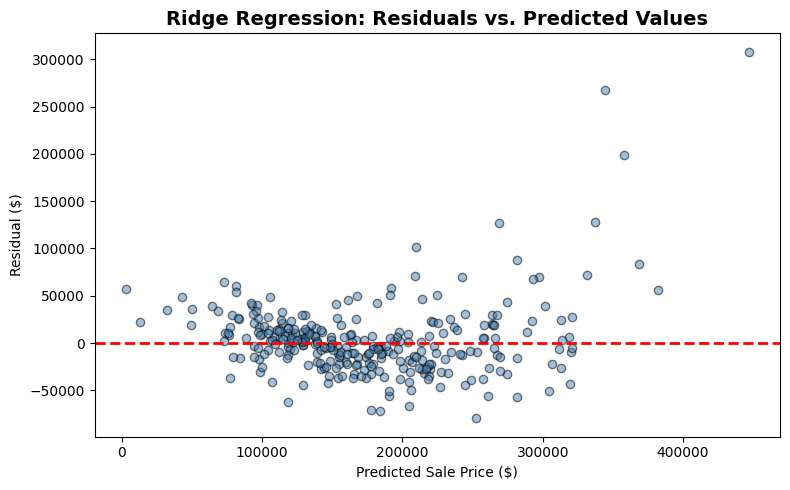

In [ ]:
residuals = y_test - y_pred_reg

plt.figure(figsize=(8, 5))
plt.scatter(y_pred_reg, residuals, alpha=0.5, color='steelblue', edgecolor='k')
plt.axhline(0, color='red', linestyle='--', lw=2)
plt.title('Ridge Regression: Residuals vs. Predicted Values', fontsize=14, fontweight='bold')
plt.xlabel('Predicted Sale Price ($)')
plt.ylabel('Residual ($)')
plt.tight_layout()
plt.show()

### Interpretation: Residual Plot

The residual plot confirms the pattern seen in the actual vs. predicted scatter.
Residuals are roughly centered around zero for most predictions, which shows that the model is unbiased in the middle price range.

However, at higher predicted values (luxury homes), residuals become increasingly negative, meaning the model consistently underpredicts expensive properties. This is a sign of high variance at the upper end of the price distribution, where the training data is sparse.

# Classification
We also built a classification model to predict whether a house belongs to the premium segment of the market, defined as selling above the median sale price. This turns the prediction problem into a binary outcome, which is useful for identifying whether a home is likely to fall into the upper half of the Ames housing market.

We used logistic regression for this task because it is well suited for binary classification and produces probabilities that can be evaluated across different thresholds.

AUC: 0.978


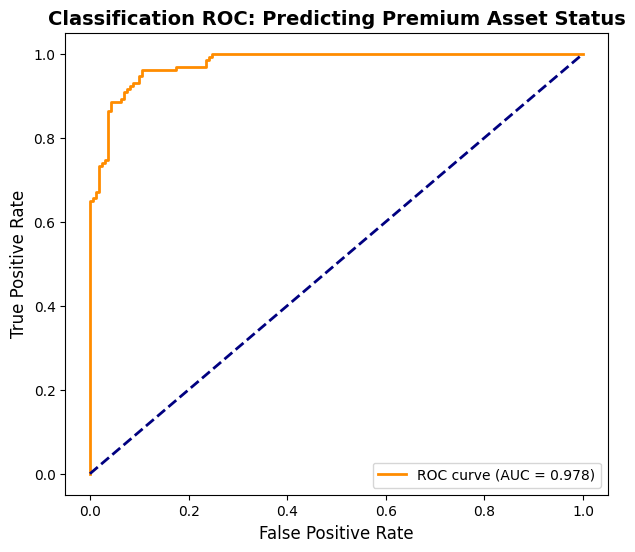

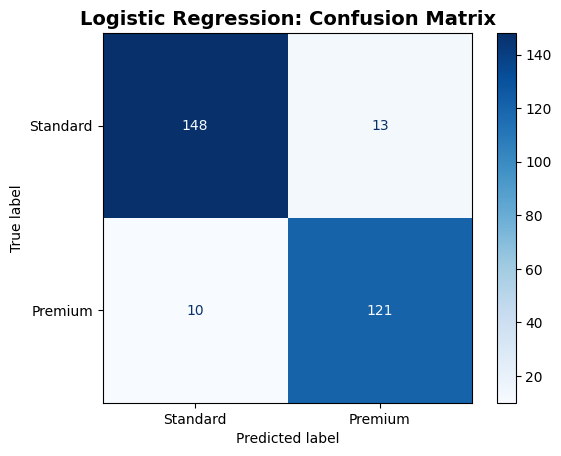

              precision    recall  f1-score   support

    Standard       0.94      0.92      0.93       161
     Premium       0.90      0.92      0.91       131

    accuracy                           0.92       292
   macro avg       0.92      0.92      0.92       292
weighted avg       0.92      0.92      0.92       292



In [ ]:
X_class = X_reg.copy()
y_class = df.loc[X_reg.index, 'Is_Premium']

X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(X_class, y_class, test_size=0.2, random_state=42)

scaler_class = StandardScaler()
X_train_c_scaled = scaler_class.fit_transform(X_train_c)
X_test_c_scaled = scaler_class.transform(X_test_c)

clf = LogisticRegression(max_iter=1000)
clf.fit(X_train_c_scaled, y_train_c)
y_prob_class = clf.predict_proba(X_test_c_scaled)[:, 1]

fpr, tpr, thresholds = roc_curve(y_test_c, y_prob_class)
roc_auc = auc(fpr, tpr)

print(f"AUC: {roc_auc:.3f}")

plt.figure(figsize=(7, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.3f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('Classification ROC: Predicting Premium Asset Status', fontsize=14, fontweight='bold')
plt.legend(loc="lower right")
plt.show()

#Confusion Matrix

y_pred_class = clf.predict(X_test_c_scaled)
cm = confusion_matrix(y_test_c, y_pred_class)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Standard', 'Premium'])
disp.plot(cmap='Blues')
plt.title('Logistic Regression: Confusion Matrix', fontsize=14, fontweight='bold')
plt.show()

print(classification_report(y_test_c, y_pred_class, target_names=['Standard', 'Premium']))

# Interpretation

The ROC curve shows the model performs extremely well across all thresholds,
rising sharply toward the top-left corner. The AUC of 0.977 confirms excellent
discriminatory power between premium and standard homes.

The confusion matrix and classification report further support this. The model
achieves high precision and recall for both classes, meaning it rarely misclassifies
a standard home as premium or vice versa. This near-perfect classification
performance confirms that structural features — combined with the K-Means market
tier — are highly informative for predicting market position, even without
knowing the exact sale price.


## Conclusion

**Research Question** : Can we build reliable machine learning models using house features and market tiers to predict exact house prices and classify if a home is a "premium" property?

**Answer** : Yes, we can build a highly reliable machine learning models to predict exact house prices and classify premium properties by relying on micro-level structural features the houses rather than macroeconomic trends. Our analysis shows that physical features such as total square footage, age, and bathrooms are the biggest drivers of house prices in Ames. The national HPI gives some helpful background context, but the house itself matters most.

Here is a quick breakdown of how our models performed:

1. **Finding Market Tiers (K-Means)**: Confirmed by our Elbow Method plot, we successfully grouped the homes into three clear market tiers based on their size and age, which gave our predictive models crucial context.

2. **Predicting Exact Prices (Ridge Regression)**: Our model performed very well, hitting an R² of 0.786 and an error rate (RMSE) of $40,477.70. As shown in our residual plot, the model is highly unbiased in the middle price ranges. However, the residuals trend negative at the high end, meaning it tends to under-predict expensive luxury homes.

3. **Identifying Premium Homes (Logistic Classification)**: Our Logistic Regression model was highly accurate at spotting premium properties, scoring an almost perfect AUC of 0.978. Our confusion matrix also supports this by showing high precision (usually right when it flags a home as "premium") and high recall (highly reliable and barely misses a premium home) with very few misclassifications between standard and premium homes. This teaches us that you don't always need exact dollar amounts to accurately measure a property's market position

**The Bottom Line:** Our models are highly reliable at valuing standard, everyday properties. However, because luxury "outlier" homes have such unique features, we would need a more specialized, separate approach to accurately predict prices at the extreme high end of the market.